In [1]:
# import libraries 
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm

In [2]:
X = np.array([
    [100,5], # Apple
    [105,4], # Apple
    [90 ,5.5], # Apple
    [150,7], # Orange
    [140,6], # Orange
    [160,7.5] # Orange
])
y = np.array([0,0,0,1,1,1]) # labels = 0 = Apple , 1 = Orange

In [3]:
# Step 2 Train SVM (Linear , soft margin)
model = svm.SVC(
    kernel = "linear",
    C = 1.0 # allows some errors
)
model.fit(X,y)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [4]:
# Step 3 Hyperplane and support vectors
support_vectors = model.support_vectors_ # closest point 
w = model.coef_[0] # Hyperplane
b = model.intercept_[0] # Bais

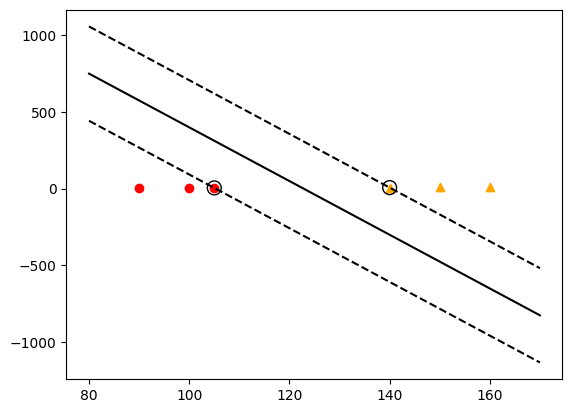

In [5]:
# step 4 plots , boundary , margins , and support vectors
# Plot apple (red) and Orange (Orange color)
plt.scatter(X[y==0][:, 0],X[y==0][:, 1],color='red',label="Apple",marker='o')
plt.scatter(X[y==1][:, 0],X[y==1][:, 1],color='orange',label="Orange",marker='^')

# support vectors 
plt.scatter(support_vectors[:, 0],support_vectors[:, 1],s=100,facecolors='none',edgecolors='black',label="Support Vectors")

# plot decision boundary (w0*x0 + w1*x1 + b = 0)
x0 = np.linspace(80,170,100) # weight range
x1 = -(w[0] * x0 + b) / w[1] # size

plt.plot(x0 , x1 , 'k-' , label = "decision boundary")

# plot margin (w0*x0 + w1*x1 + b = +1/-1)
x1_margin1 = -(w[0] * x0 + b - 1) / w[1] # upper margin 
x1_margin2 = -(w[0] * x0 + b + 1) / w[1] # Lower margin 

plt.plot(x0,x1_margin1,'k--',label= "Margins")
plt.plot(x0,x1_margin2,'k--',label= "Margins")
plt.show()

In [10]:
# predicted new Fruit

new_fruit = np.array([[125,5.7]])
prediction = model.predict(new_fruit)
print(f"New Fruit {new_fruit} is {'apple' if prediction[0] == 0 else 'orange'}")

New Fruit [[125.    5.7]] is orange


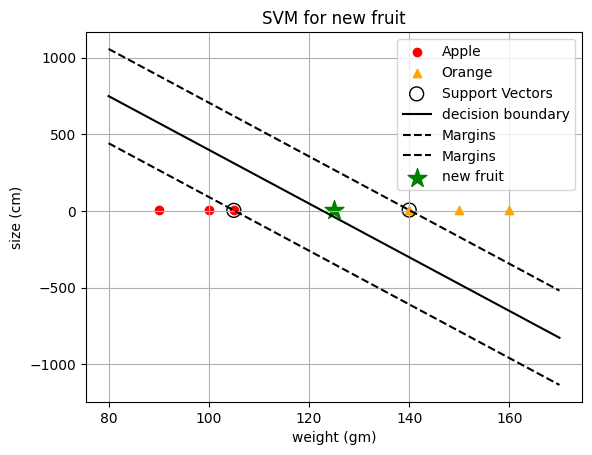

In [ ]:
# step 4 plots , boundary , margins , and support vectors
# Plot apple (red) and Orange (Orange color)
plt.scatter(X[y==0][:, 0],X[y==0][:, 1],color='red',label="Apple",marker='o')
plt.scatter(X[y==1][:, 0],X[y==1][:, 1],color='orange',label="Orange",marker='^')
# support vectors 
plt.scatter(support_vectors[:, 0],support_vectors[:, 1],s=100,facecolors='none',edgecolors='black',label="Support Vectors")

# plot decision boundary (w0*x0 + w1*x1 + b = 0)
x0 = np.linspace(80,170,100) # weight range
x1 = -(w[0] * x0 + b) / w[1] # size
plt.plot(x0 , x1 , 'k-' , label = "decision boundary")
# plot margin (w0*x0 + w1*x1 + b = +1/-1)
x1_margin1 = -(w[0] * x0 + b - 1) / w[1] # upper margin 
x1_margin2 = -(w[0] * x0 + b + 1) / w[1] # Lower margin 

plt.plot(x0,x1_margin1,'k--',label= "Margins")
plt.plot(x0,x1_margin2,'k--',label= "Margins")
# --------------------
plt.scatter(new_fruit[:, 0],new_fruit[:, 1],color='green',marker="*", s= 200,label="new fruit")
plt.title("SVM for new fruit")
plt.xlabel("weight (gm)")
plt.ylabel("size (cm)")
plt.legend()
plt.grid(True)
plt.show()